# Kết quả thực nghiệm - Multimodal Fundus Disease Recognition

Notebook này trực quan hóa kết quả training và đánh giá của mô hình **MultimodalFundusModel** trên bộ dữ liệu ODIR.

**Cấu hình thực nghiệm:**
- Image size: 128×128
- Batch size: 16
- Epochs: 20
- Learning rate: 0.0001
- Optimizer: Adam (weight decay=1e-5)
- Loss: BCELoss
- Tổng tham số: 287,896

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# ============================================================
# Dữ liệu từ quá trình training
# ============================================================

epochs = list(range(1, 21))

train_losses = [
    0.5451, 0.3871, 0.3777, 0.3734, 0.3722,
    0.3688, 0.3654, 0.3651, 0.3631, 0.3613,
    0.3607, 0.3593, 0.3569, 0.3577, 0.3535,
    0.3554, 0.3507, 0.3497, 0.3493, 0.3481
]

val_losses = [
    0.3707, 0.3537, 0.3511, 0.3516, 0.3508,
    0.3491, 0.3483, 0.3482, 0.3465, 0.3462,
    0.3452, 0.3447, 0.3443, 0.3436, 0.3427,
    0.3406, 0.3396, 0.3377, 0.3369, 0.3349
]

train_accs = [
    0.8008, 0.8382, 0.8417, 0.8419, 0.8451,
    0.8447, 0.8470, 0.8471, 0.8499, 0.8498,
    0.8503, 0.8513, 0.8509, 0.8515, 0.8515,
    0.8514, 0.8516, 0.8511, 0.8523, 0.8516
]

val_accs = [0.8523] * 20  # Val accuracy ổn định

# Per-class test accuracy
class_names = ['N\n(Normal)', 'D\n(Diabetes)', 'G\n(Glaucoma)', 'C\n(Cataract)',
               'A\n(AMD)', 'H\n(Hypertension)', 'M\n(Myopia)', 'O\n(Others)']
class_names_short = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
class_accs = [0.6743, 0.6886, 0.9229, 0.9486, 0.9600, 0.9486, 0.9486, 0.7314]
overall_acc = 0.8529

# Dataset split
split_names = ['Train', 'Validation', 'Test']
split_counts = [2450, 700, 350]

# Batch-level loss (Epoch 1, every 10 batches)
batch_steps = list(range(10, 155, 10))
batch_losses_ep1 = [
    0.6816, 0.6600, 0.6457, 0.6141, 0.6070,
    0.6080, 0.5706, 0.5144, 0.5130, 0.4912,
    0.4893, 0.4251, 0.4393, 0.3866, 0.3881
]

print('Data loaded.')
print(f'Epochs: {len(epochs)}')
print(f'Best Val Loss: {min(val_losses):.4f} (Epoch {val_losses.index(min(val_losses))+1})')
print(f'Best Val Accuracy: {max(val_accs):.4f}')
print(f'Overall Test Hamming Accuracy: {overall_acc:.4f}')

Data loaded.
Epochs: 20
Best Val Loss: 0.3349 (Epoch 20)
Best Val Accuracy: 0.8523
Overall Test Hamming Accuracy: 0.8529


---
## Chart 1: Đường cong Loss trong quá trình huấn luyện

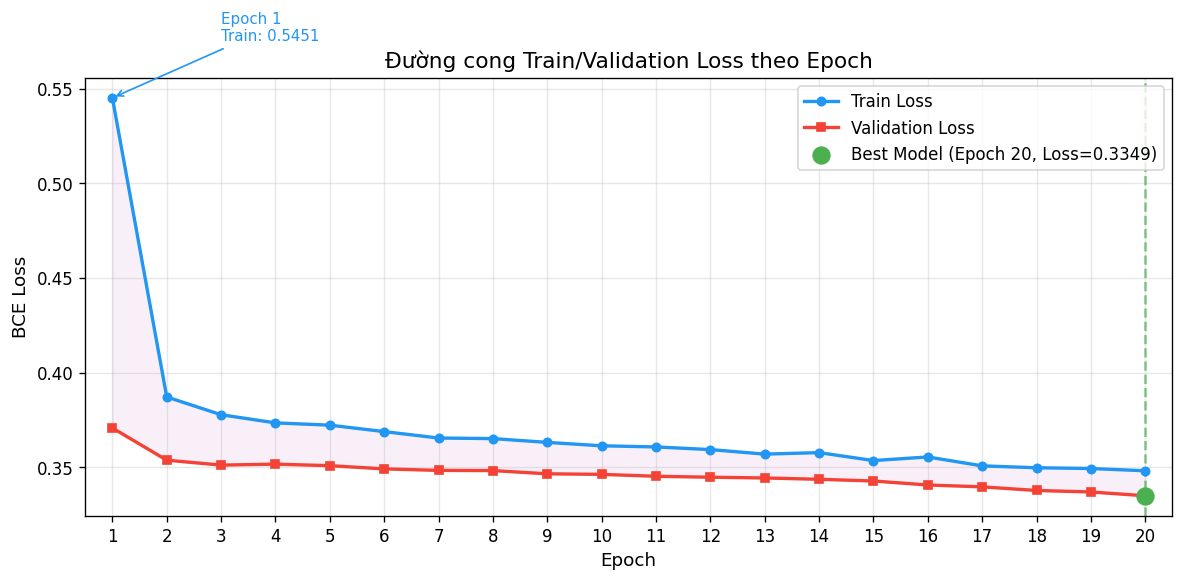

Saved: chart_result_01_loss_curve.png


In [3]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(epochs, train_losses, 'o-', color='#2196F3', linewidth=2,
        markersize=5, label='Train Loss', zorder=3)
ax.plot(epochs, val_losses, 's-', color='#F44336', linewidth=2,
        markersize=5, label='Validation Loss', zorder=3)

# Đánh dấu best model
best_epoch = val_losses.index(min(val_losses)) + 1
best_loss = min(val_losses)
ax.axvline(x=best_epoch, color='#4CAF50', linestyle='--', alpha=0.7, linewidth=1.5)
ax.scatter([best_epoch], [best_loss], color='#4CAF50', s=100, zorder=5,
           label=f'Best Model (Epoch {best_epoch}, Loss={best_loss:.4f})')

ax.fill_between(epochs, train_losses, val_losses, alpha=0.07, color='#9C27B0')

ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title('Đường cong Train/Validation Loss theo Epoch')
ax.legend(loc='upper right')
ax.set_xticks(epochs)
ax.set_xlim(0.5, 20.5)

# Annotations
ax.annotate(f'Epoch 1\nTrain: {train_losses[0]:.4f}',
            xy=(1, train_losses[0]), xytext=(3, train_losses[0]+0.03),
            arrowprops=dict(arrowstyle='->', color='#2196F3'),
            fontsize=9, color='#2196F3')

plt.tight_layout()
plt.savefig('chart_result_01_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart_result_01_loss_curve.png')

---
## Chart 2: Đường cong Hamming Accuracy trong quá trình huấn luyện

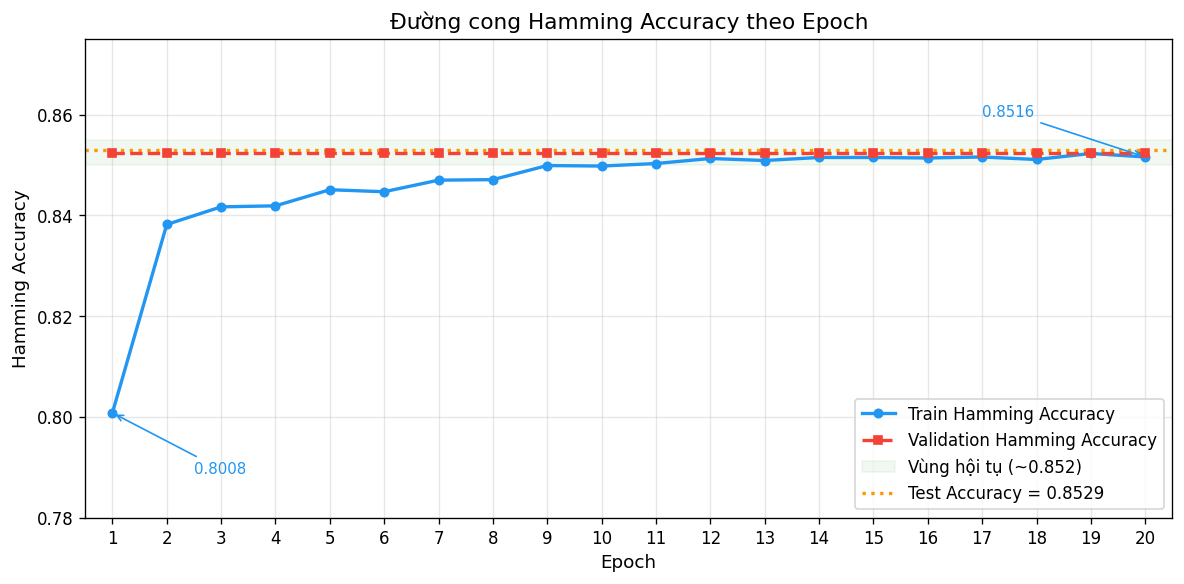

Saved: chart_result_02_accuracy_curve.png


In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(epochs, train_accs, 'o-', color='#2196F3', linewidth=2,
        markersize=5, label='Train Hamming Accuracy', zorder=3)
ax.plot(epochs, val_accs, 's--', color='#F44336', linewidth=2,
        markersize=5, label='Validation Hamming Accuracy', zorder=3)

# Vùng hội tụ
ax.axhspan(0.850, 0.855, alpha=0.08, color='#4CAF50', label='Vùng hội tụ (~0.852)')
ax.axhline(y=overall_acc, color='#FF9800', linestyle=':', linewidth=2,
           label=f'Test Accuracy = {overall_acc:.4f}')

ax.set_xlabel('Epoch')
ax.set_ylabel('Hamming Accuracy')
ax.set_title('Đường cong Hamming Accuracy theo Epoch')
ax.legend(loc='lower right')
ax.set_xticks(epochs)
ax.set_xlim(0.5, 20.5)
ax.set_ylim(0.78, 0.875)

# Annotation epoch 1 vs epoch cuoi
ax.annotate(f'{train_accs[0]:.4f}',
            xy=(1, train_accs[0]), xytext=(2.5, train_accs[0]-0.012),
            arrowprops=dict(arrowstyle='->', color='#2196F3'),
            fontsize=9, color='#2196F3')
ax.annotate(f'{train_accs[-1]:.4f}',
            xy=(20, train_accs[-1]), xytext=(17, train_accs[-1]+0.008),
            arrowprops=dict(arrowstyle='->', color='#2196F3'),
            fontsize=9, color='#2196F3')

plt.tight_layout()
plt.savefig('chart_result_02_accuracy_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart_result_02_accuracy_curve.png')

---
## Chart 3: Hamming Accuracy theo từng nhãn bệnh trên tập Test

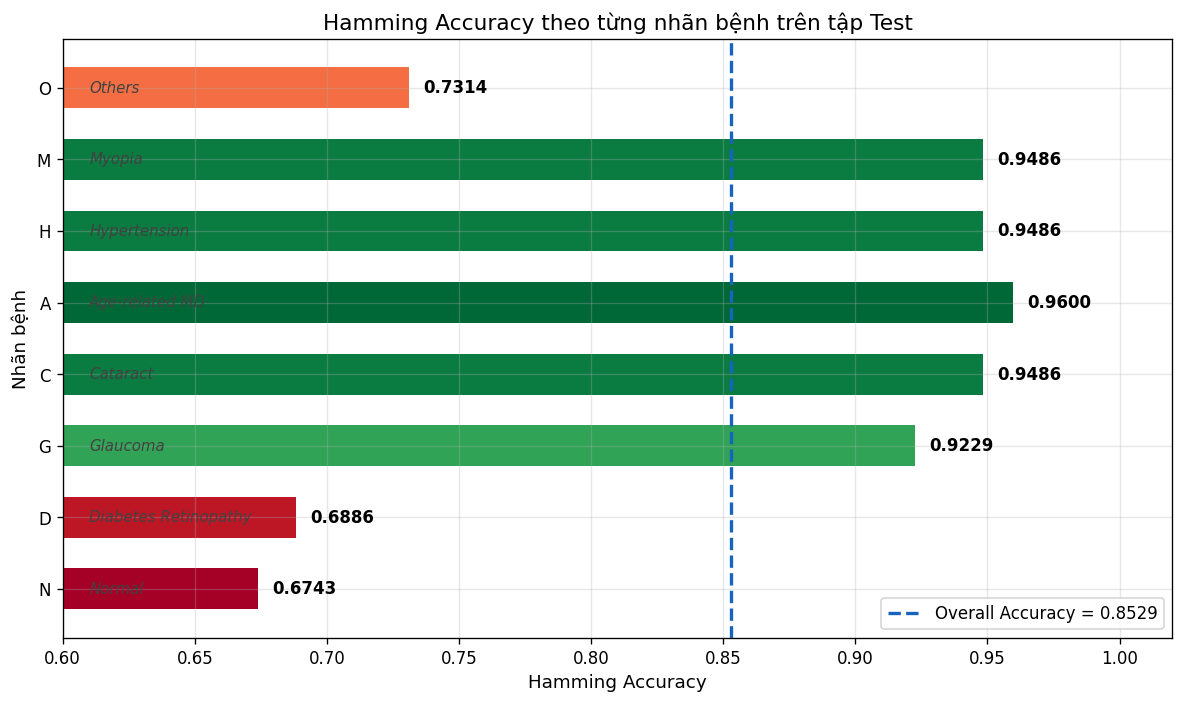

Saved: chart_result_03_per_class_accuracy.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

# Màu gradient theo giá trị accuracy
cmap = plt.cm.RdYlGn
norm_vals = [(v - min(class_accs)) / (max(class_accs) - min(class_accs)) for v in class_accs]
colors = [cmap(v) for v in norm_vals]

bars = ax.barh(class_names_short, class_accs, color=colors, edgecolor='white',
               linewidth=1.2, height=0.6)

# Overall accuracy line
ax.axvline(x=overall_acc, color='#1565C0', linestyle='--', linewidth=2,
           label=f'Overall Accuracy = {overall_acc:.4f}', zorder=5)

# Value labels
for bar, val in zip(bars, class_accs):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Hamming Accuracy')
ax.set_ylabel('Nhãn bệnh')
ax.set_title('Hamming Accuracy theo từng nhãn bệnh trên tập Test')
ax.set_xlim(0.60, 1.02)
ax.legend(loc='lower right')

# Tên đầy đủ bên cạnh
disease_names = ['Normal', 'Diabetes Retinopathy', 'Glaucoma', 'Cataract',
                 'Age-related MD', 'Hypertension', 'Myopia', 'Others']
for i, name in enumerate(disease_names):
    ax.text(0.61, i, name, va='center', fontsize=9, color='#424242', style='italic')

plt.tight_layout()
plt.savefig('chart_result_03_per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart_result_03_per_class_accuracy.png')

---
## Chart 4: Phân phối tập dữ liệu (Train / Validation / Test)

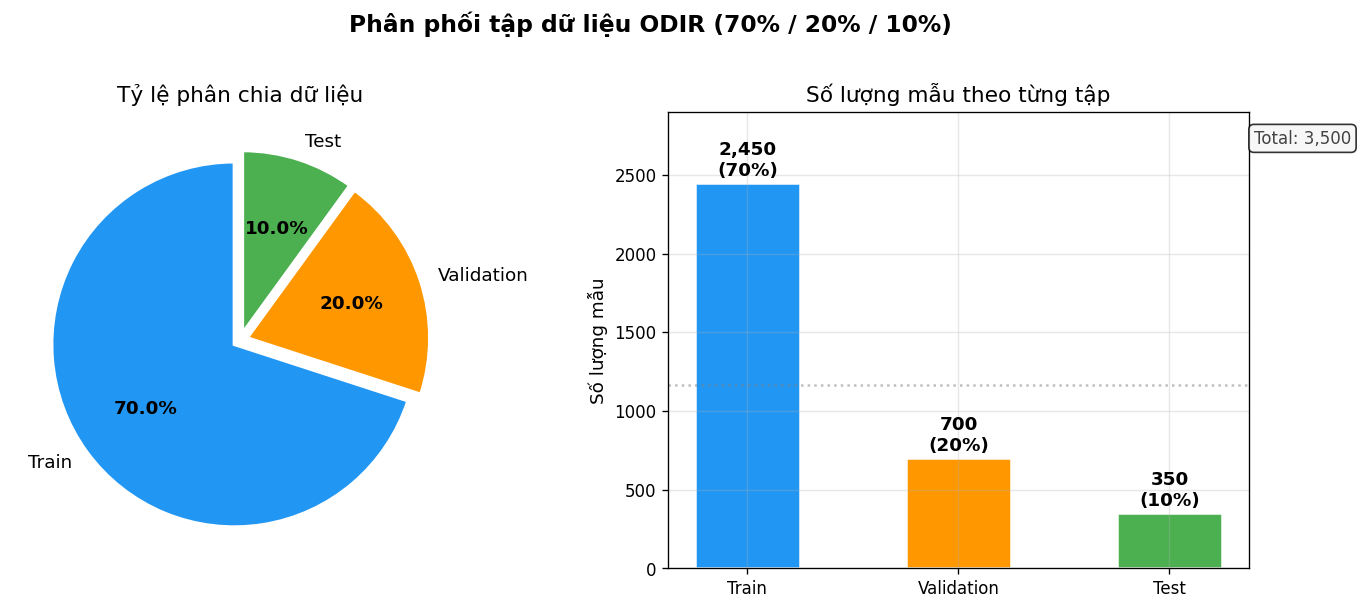

Saved: chart_result_04_dataset_split.png


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

colors_split = ['#2196F3', '#FF9800', '#4CAF50']
explode = (0.04, 0.04, 0.04)

# Pie chart
wedges, texts, autotexts = ax1.pie(
    split_counts,
    labels=split_names,
    colors=colors_split,
    explode=explode,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 11},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
ax1.set_title('Tỷ lệ phân chia dữ liệu', fontsize=13)

# Bar chart
bars = ax2.bar(split_names, split_counts, color=colors_split,
               edgecolor='white', linewidth=1.5, width=0.5)
for bar, count in zip(bars, split_counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{count:,}\n({count/3500*100:.0f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.set_ylabel('Số lượng mẫu')
ax2.set_title('Số lượng mẫu theo từng tập', fontsize=13)
ax2.set_ylim(0, 2900)
ax2.axhline(y=3500/3, color='gray', linestyle=':', alpha=0.5)

# Tổng
ax2.text(2.4, 2700, f'Total: 3,500', fontsize=10, color='#424242',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#F5F5F5', alpha=0.8))

plt.suptitle('Phân phối tập dữ liệu ODIR (70% / 20% / 10%)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart_result_04_dataset_split.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart_result_04_dataset_split.png')

---
## Chart 5: Batch Loss trong Epoch 1 — Quá trình hội tụ ban đầu

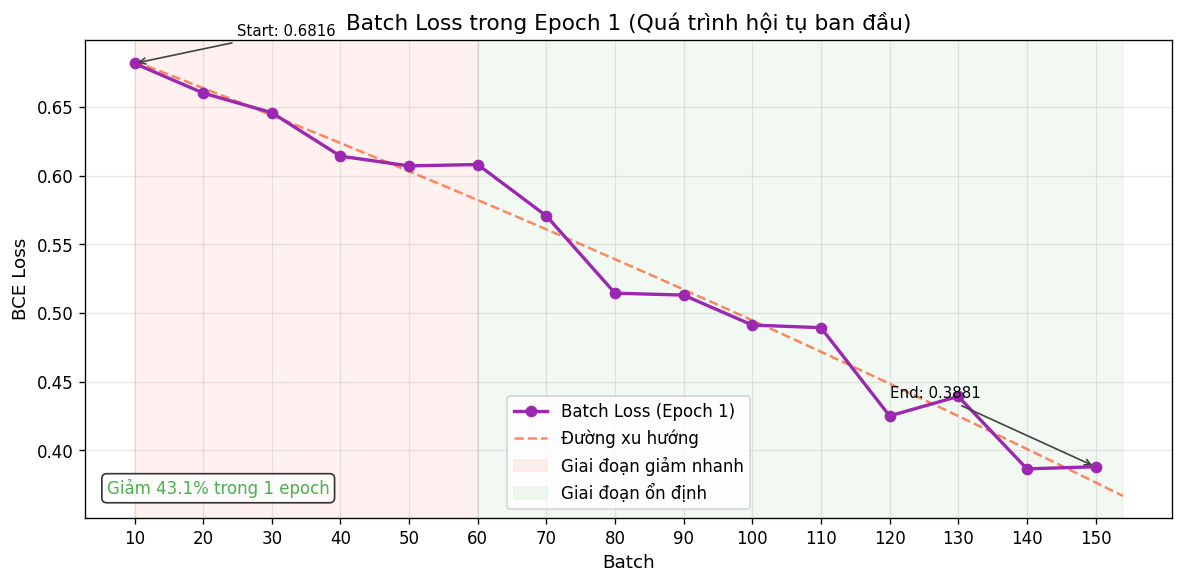

Saved: chart_result_05_batch_loss_ep1.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(batch_steps, batch_losses_ep1, 'o-', color='#9C27B0', linewidth=2,
        markersize=6, label='Batch Loss (Epoch 1)', zorder=3)

# Xu hướng (trend line)
z = np.polyfit(batch_steps, batch_losses_ep1, 2)
p = np.poly1d(z)
x_trend = np.linspace(10, 154, 100)
ax.plot(x_trend, p(x_trend), '--', color='#FF5722', linewidth=1.5,
        alpha=0.7, label='Đường xu hướng')

# Vùng giảm nhanh
ax.axvspan(10, 60, alpha=0.07, color='#F44336', label='Giai đoạn giảm nhanh')
ax.axvspan(60, 154, alpha=0.07, color='#4CAF50', label='Giai đoạn ổn định')

ax.set_xlabel('Batch')
ax.set_ylabel('BCE Loss')
ax.set_title('Batch Loss trong Epoch 1 (Quá trình hội tụ ban đầu)')
ax.legend()
ax.set_xticks(batch_steps)

# Annotations
ax.annotate(f'Start: {batch_losses_ep1[0]:.4f}',
            xy=(10, batch_losses_ep1[0]), xytext=(25, batch_losses_ep1[0]+0.02),
            arrowprops=dict(arrowstyle='->', color='#424242'), fontsize=9)
ax.annotate(f'End: {batch_losses_ep1[-1]:.4f}',
            xy=(150, batch_losses_ep1[-1]), xytext=(120, batch_losses_ep1[-1]+0.05),
            arrowprops=dict(arrowstyle='->', color='#424242'), fontsize=9)

drop_pct = (batch_losses_ep1[0] - batch_losses_ep1[-1]) / batch_losses_ep1[0] * 100
ax.text(0.02, 0.05, f'Giảm {drop_pct:.1f}% trong 1 epoch',
        transform=ax.transAxes, fontsize=10, color='#4CAF50',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('chart_result_05_batch_loss_ep1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart_result_05_batch_loss_ep1.png')

---
## Chart 6: Mức cải thiện Validation Loss theo từng Epoch

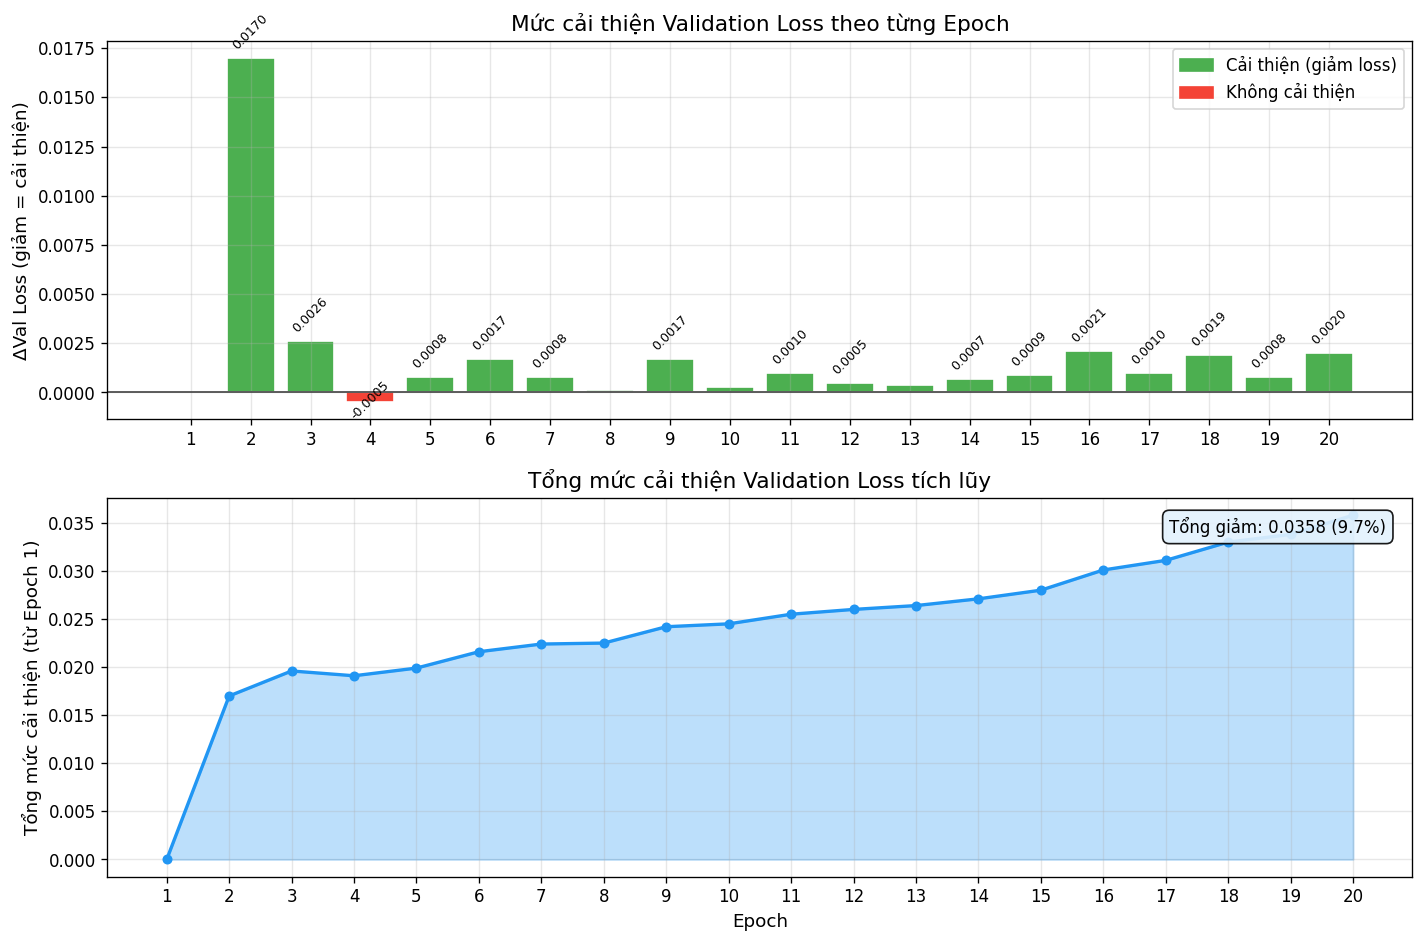

Saved: chart_result_06_loss_improvement.png


In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [1, 1]})

# Chart 6a: Delta Val Loss
delta_val = [0] + [val_losses[i-1] - val_losses[i] for i in range(1, len(val_losses))]
colors_delta = ['#4CAF50' if d > 0 else '#F44336' for d in delta_val]
bars = ax1.bar(epochs, delta_val, color=colors_delta, edgecolor='white', linewidth=1)
ax1.axhline(y=0, color='#424242', linewidth=1)
for bar, val in zip(bars, delta_val):
    if abs(val) > 0.0005:
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + (0.0003 if val >= 0 else -0.001),
                 f'{val:.4f}', ha='center', va='bottom', fontsize=7.5, rotation=45)
ax1.set_ylabel('ΔVal Loss (giảm = cải thiện)')
ax1.set_title('Mức cải thiện Validation Loss theo từng Epoch')
ax1.set_xticks(epochs)
good_patch = mpatches.Patch(color='#4CAF50', label='Cải thiện (giảm loss)')
bad_patch = mpatches.Patch(color='#F44336', label='Không cải thiện')
ax1.legend(handles=[good_patch, bad_patch], loc='upper right')

# Chart 6b: Cumulative improvement
cum_improvement = [val_losses[0] - v for v in val_losses]
ax2.fill_between(epochs, cum_improvement, alpha=0.3, color='#2196F3')
ax2.plot(epochs, cum_improvement, 'o-', color='#2196F3', linewidth=2, markersize=5)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Tổng mức cải thiện (từ Epoch 1)')
ax2.set_title('Tổng mức cải thiện Validation Loss tích lũy')
ax2.set_xticks(epochs)

total_drop = val_losses[0] - val_losses[-1]
ax2.text(0.98, 0.95, f'Tổng giảm: {total_drop:.4f} ({total_drop/val_losses[0]*100:.1f}%)',
         transform=ax2.transAxes, fontsize=10, ha='right', va='top',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#E3F2FD', alpha=0.9))

plt.tight_layout()
plt.savefig('chart_result_06_loss_improvement.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart_result_06_loss_improvement.png')

---
## Chart 7: Dashboard Tổng hợp Kết quả Thực nghiệm

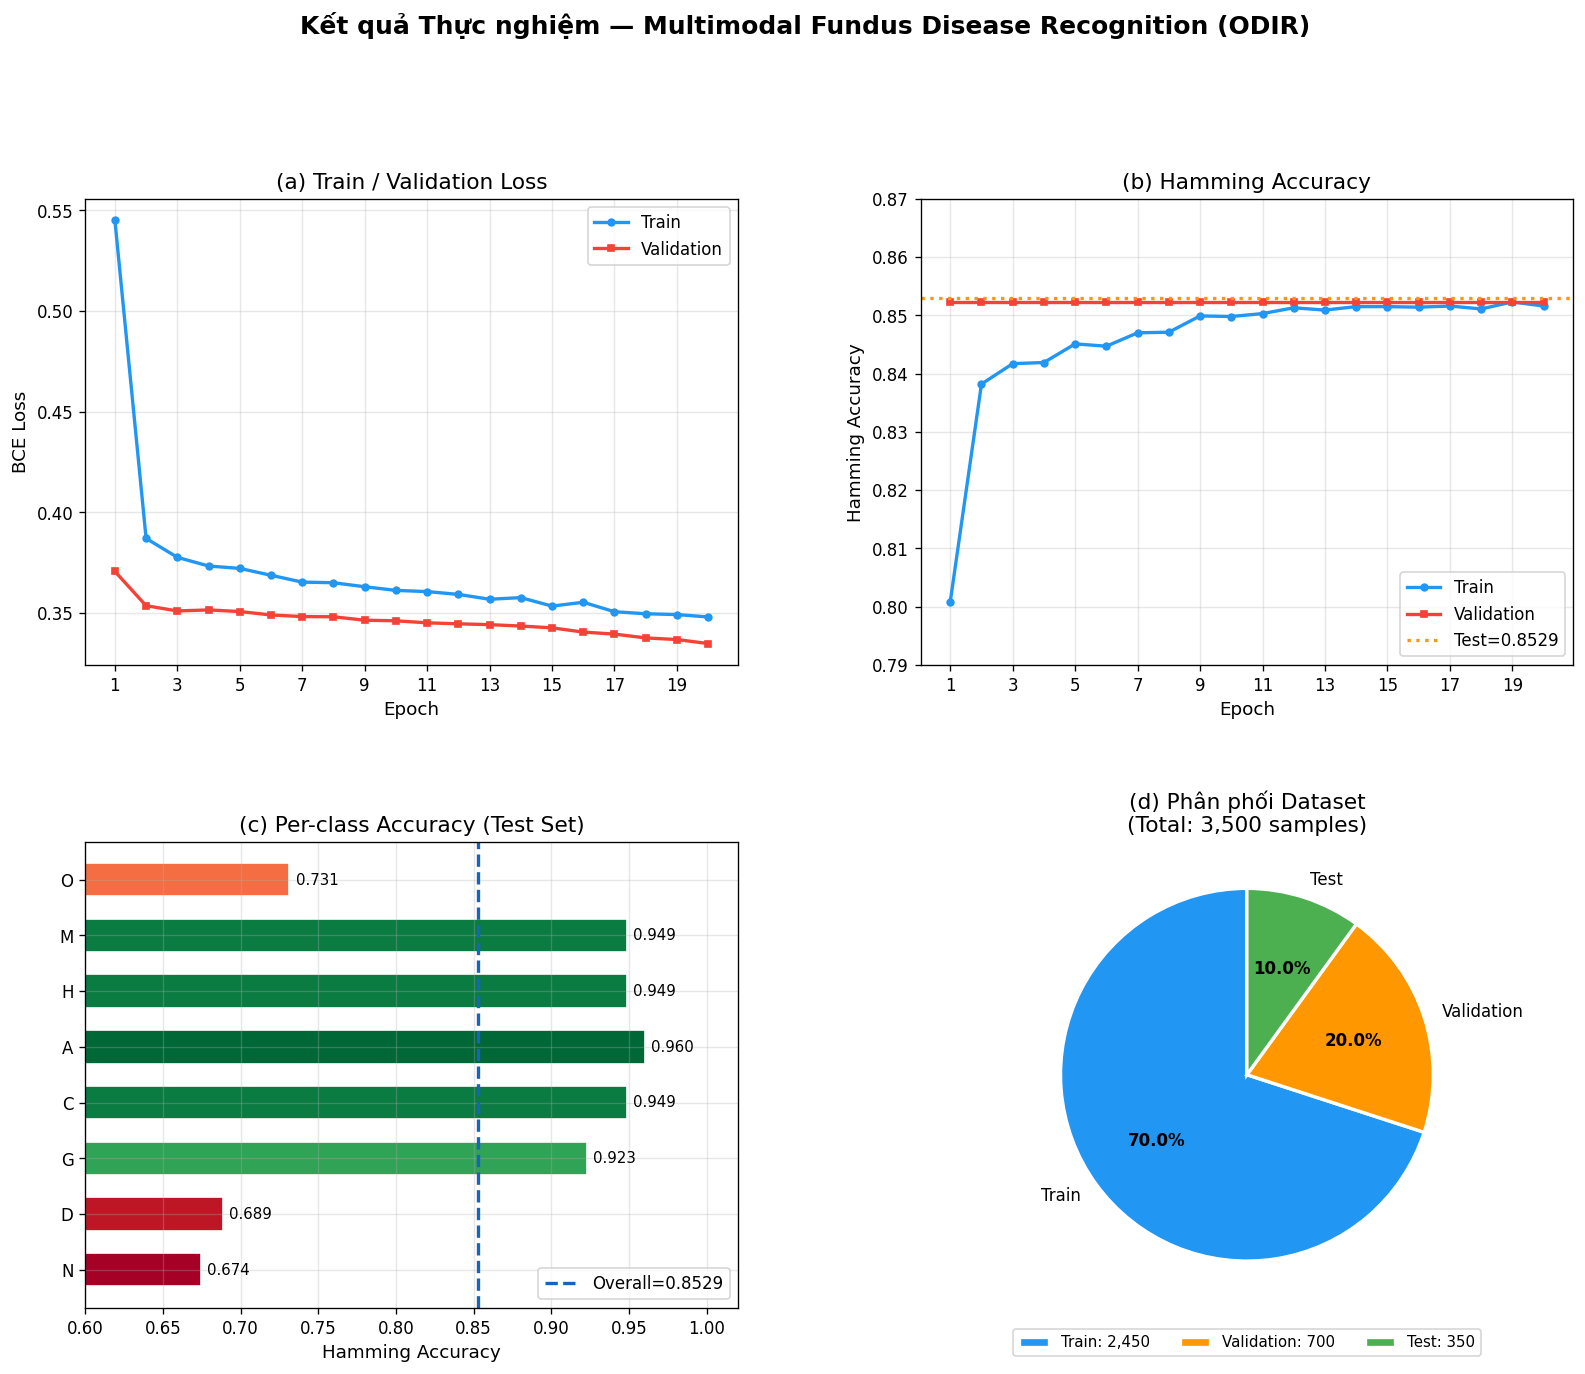

Saved: chart_result_07_dashboard.png


In [9]:
fig = plt.figure(figsize=(16, 12))
gs = GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.28)

ax_loss    = fig.add_subplot(gs[0, 0])
ax_acc     = fig.add_subplot(gs[0, 1])
ax_class   = fig.add_subplot(gs[1, 0])
ax_split   = fig.add_subplot(gs[1, 1])

# --- Panel 1: Loss ---
ax_loss.plot(epochs, train_losses, 'o-', color='#2196F3', linewidth=2, markersize=4, label='Train')
ax_loss.plot(epochs, val_losses,   's-', color='#F44336', linewidth=2, markersize=4, label='Validation')
ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('BCE Loss')
ax_loss.set_title('(a) Train / Validation Loss')
ax_loss.legend(); ax_loss.set_xticks(range(1, 21, 2))

# --- Panel 2: Accuracy ---
ax_acc.plot(epochs, train_accs, 'o-', color='#2196F3', linewidth=2, markersize=4, label='Train')
ax_acc.plot(epochs, val_accs,   's-', color='#F44336', linewidth=2, markersize=4, label='Validation')
ax_acc.axhline(y=overall_acc, color='#FF9800', linestyle=':', linewidth=2,
               label=f'Test={overall_acc:.4f}')
ax_acc.set_xlabel('Epoch'); ax_acc.set_ylabel('Hamming Accuracy')
ax_acc.set_title('(b) Hamming Accuracy')
ax_acc.legend(loc='lower right'); ax_acc.set_xticks(range(1, 21, 2))
ax_acc.set_ylim(0.79, 0.87)

# --- Panel 3: Per-class accuracy ---
cmap = plt.cm.RdYlGn
norm_vals = [(v - min(class_accs)) / (max(class_accs) - min(class_accs)) for v in class_accs]
colors_c = [cmap(v) for v in norm_vals]
ax_class.barh(class_names_short, class_accs, color=colors_c, edgecolor='white', height=0.6)
ax_class.axvline(x=overall_acc, color='#1565C0', linestyle='--', linewidth=2,
                 label=f'Overall={overall_acc:.4f}')
for i, val in enumerate(class_accs):
    ax_class.text(val + 0.004, i, f'{val:.3f}', va='center', fontsize=9)
ax_class.set_xlabel('Hamming Accuracy')
ax_class.set_title('(c) Per-class Accuracy (Test Set)')
ax_class.legend(loc='lower right'); ax_class.set_xlim(0.60, 1.02)

# --- Panel 4: Dataset split ---
colors_s = ['#2196F3', '#FF9800', '#4CAF50']
wedges, texts, autotexts = ax_split.pie(
    split_counts, labels=split_names, colors=colors_s,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for t in autotexts: t.set_fontsize(10); t.set_fontweight('bold')
ax_split.set_title(f'(d) Phân phối Dataset\n(Total: 3,500 samples)')

# Thêm legend với số lượng cụ thể
legend_labels = [f'{n}: {c:,}' for n, c in zip(split_names, split_counts)]
ax_split.legend(legend_labels, loc='lower center', bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=9)

fig.suptitle('Kết quả Thực nghiệm — Multimodal Fundus Disease Recognition (ODIR)',
             fontsize=15, fontweight='bold', y=1.01)

plt.savefig('chart_result_07_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart_result_07_dashboard.png')

---
## Tóm tắt kết quả

In [10]:
print('=' * 60)
print('TÓM TẮT KẾT QUẢ THỰC NGHIỆM')
print('=' * 60)
print(f'Mô hình        : MultimodalFundusModel (LightweightCNN)')
print(f'Tham số        : 287,896')
print(f'Epochs         : 20')
print(f'Batch size     : 16')
print(f'Learning rate  : 0.0001')
print('-' * 60)
print(f'Train Loss     : {train_losses[0]:.4f} (ep.1) → {train_losses[-1]:.4f} (ep.20)')
print(f'Val Loss       : {val_losses[0]:.4f} (ep.1) → {val_losses[-1]:.4f} (ep.20)')
print(f'Train Accuracy : {train_accs[0]:.4f} (ep.1) → {train_accs[-1]:.4f} (ep.20)')
print(f'Val Accuracy   : {val_accs[0]:.4f} (ổn định qua các epoch)')
print('-' * 60)
print(f'Test Hamming Accuracy (Overall): {overall_acc:.4f}')
print('Per-class:')
full_names = ['Normal', 'Diabetes', 'Glaucoma', 'Cataract', 'AMD', 'Hypertension', 'Myopia', 'Others']
for name, short, acc in zip(full_names, class_names_short, class_accs):
    bar = '█' * int(acc * 20)
    print(f'  {short} ({name:<14}): {acc:.4f}  {bar}')
print('=' * 60)
print('\nFiles đã tạo:')
for i in range(1, 8):
    names = [
        'Loss Curve',
        'Accuracy Curve',
        'Per-class Accuracy',
        'Dataset Split',
        'Batch Loss (Epoch 1)',
        'Loss Improvement',
        'Dashboard (Tổng hợp)'
    ]
    print(f'  chart_result_0{i}_{names[i-1].lower().replace(" ", "_")}.png')

TÓM TẮT KẾT QUẢ THỰC NGHIỆM
Mô hình        : MultimodalFundusModel (LightweightCNN)
Tham số        : 287,896
Epochs         : 20
Batch size     : 16
Learning rate  : 0.0001
------------------------------------------------------------
Train Loss     : 0.5451 (ep.1) → 0.3481 (ep.20)
Val Loss       : 0.3707 (ep.1) → 0.3349 (ep.20)
Train Accuracy : 0.8008 (ep.1) → 0.8516 (ep.20)
Val Accuracy   : 0.8523 (ổn định qua các epoch)
------------------------------------------------------------
Test Hamming Accuracy (Overall): 0.8529
Per-class:
  N (Normal        ): 0.6743  █████████████
  D (Diabetes      ): 0.6886  █████████████
  G (Glaucoma      ): 0.9229  ██████████████████
  C (Cataract      ): 0.9486  ██████████████████
  A (AMD           ): 0.9600  ███████████████████
  H (Hypertension  ): 0.9486  ██████████████████
  M (Myopia        ): 0.9486  ██████████████████
  O (Others        ): 0.7314  ██████████████

Files đã tạo:
  chart_result_01_loss_curve.png
  chart_result_02_accuracy_curve.pn